In [3]:
import numpy as np
import sys
import pandas as pd

In [4]:
%load_ext autoreload
%autoreload 2

sys.path.append("../src") 
import visualization as visual
import data_splitting as split
import preprocessing as prep
import neural_network as MLP
import metrics as metricas

In [5]:
# cargo los datasets
X_images = np.load("../data/X_images.npy")
y_images = np.load("../data/y_images.npy")

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
1) Análisis y Preprocesamiento de Datos
</h1>

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
1.a) Examinar el dataset
</h3>

In [6]:
# Dimensiones y tipos
print("Shape X:", X_images.shape)
print("Shape y:", y_images.shape)

print("Tipo X:", X_images.dtype)
print("Tipo y:", y_images.dtype)

Shape X: (809555, 28, 28)
Shape y: (809555,)
Tipo X: uint8
Tipo y: uint8


El conjunto de imágenes `X_images` posee dimensión `(809555, 28, 28)`, lo que indica que el dataset contiene 809555 imágenes de tamaño 28×28 píxeles. Por otro lado, el vector de etiquetas `y_images` tiene dimensión `(809555,)`, indicando que existe una etiqueta asociada a cada imagen del dataset

In [7]:
# Cantidad de clases
clases_unicas = np.unique(y_images)

print("Cantidad de clases:", len(clases_unicas))
print("Clases:", clases_unicas)

Cantidad de clases: 47
Clases: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]


Luego se analizaron las etiquetas presentes en el dataset utilizando `np.unique()`, con el objetivo de identificar la cantidad de clases distintas. Se verificó que el dataset contiene 47 clases diferentes, numeradas desde 0 hasta 46, coincidiendo con lo especificado en la consigna para el conjunto EMNIST Bymerge. Cada número representa una categoría distinta correspondiente a caracteres manuscritos (letras o dígitos)

In [8]:
# Rango de valores de pixeles
print("Valor mínimo:", X_images.min())
print("Valor máximo:", X_images.max())

Valor mínimo: 0
Valor máximo: 255


También se examinó el rango de valores de los píxeles presentes en las imágenes. Se observó que los valores varían entre 0 y 255, lo cual es consistente con imágenes en escala de grises representadas con 8 bits por píxel. El valor 0 corresponde a píxeles negros, mientras que el valor 255 representa píxeles blancos

<div style="
    text-align: center;
    background-color: rgba(0, 0, 0, 0.3);
    color: white;
    padding: 10px;
    border-radius: 8px;
    font-weight: bold;
">
Visualizar imágenes
</div>

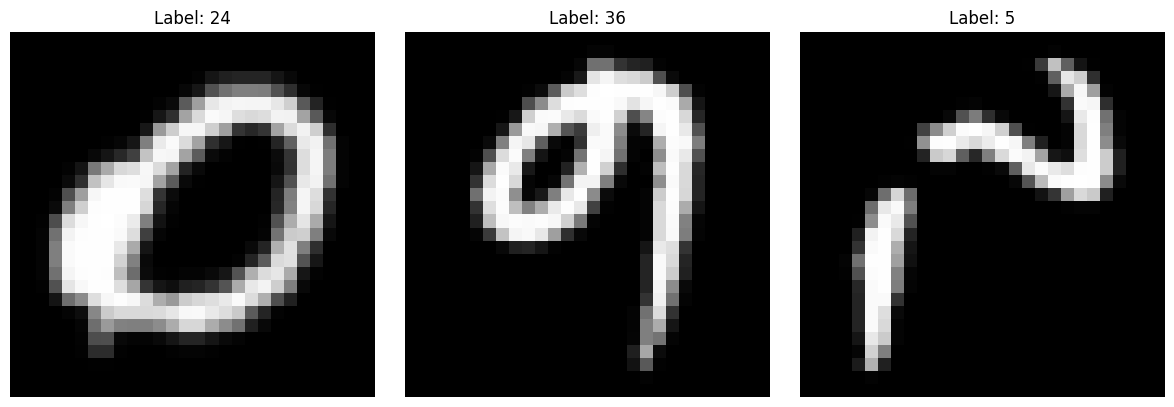

In [9]:
visual.visualizar_imagenes(X_images, y_images, cantidad=3)

Se visualizaron tres imágenes del dataset junto con sus etiquetas correspondientes. Para poder graficarlas, cada imagen fue convertida a una matriz de 28×28 píxeles mediante `reshape(28,28)`. Esto permite recuperar la forma original de la imagen, ya que cada observación representa un carácter manuscrito. Sobre cada imagen se indica su etiqueta numérica, que representa la clase a la que pertenece dentro de las 47 clases posibles del dataset.

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
1.b) Data Splitting
</h3>

In [10]:
X_tr, X_val, X_test, y_tr, y_val, y_test = split.split_train_val_test(
    X_images,
    y_images,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42
)

Se dividió el dataset en tres subconjuntos: Train, Validation y Test, utilizando una proporción 70/15/15. El 70% de los datos se asignó al conjunto de entrenamiento, ya que este subconjunto se utiliza para ajustar los pesos de la red neuronal durante el proceso de aprendizaje. El 15% se destinó al conjunto de validación, que se utilizará para comparar distintas configuraciones del modelo. Finalmente, el 15% restante se reservó como conjunto de test. Este conjunto queda separado para evaluar de manera final y objetiva la performance de los modelos entrenados.
Además, la división se realizó de forma estratificada para conservar aproximadamente la misma proporción de clases en Train, Validation y Test. Esto se hace para evitar que alguna clase quede poco representada en alguno de los subconjuntos

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
1.c) Normalización
</h3>

In [11]:
X_tr = prep.normalizar_imagenes(X_tr)
X_val = prep.normalizar_imagenes(X_val)
X_test = prep.normalizar_imagenes(X_test)

Se normalizaron las imágenes dividiendo todos los valores de píxel por 255. De esta manera, los datos quedaron escalados en el rango [0,1], donde 0 representa el valor mínimo posible y 1 el máximo. La normalización facilita el entrenamiento de la red neuronal, ya que evita trabajar con magnitudes demasiado grandes y mejora la estabilidad numérica del proceso de optimización.

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
2) Red Neuronal Básica
</h1>

In [12]:
# aplanar imágenes: de 28x28 a vectores de 784
X_tr_flat = prep.flatten_imagenes(X_tr)
X_val_flat = prep.flatten_imagenes(X_val)
X_test_flat = prep.flatten_imagenes(X_test)

# one-hot encoding de las etiquetas
y_tr_onehot = prep.one_hot_encode(y_tr, num_classes=47)
y_val_onehot = prep.one_hot_encode(y_val, num_classes=47)
y_test_onehot = prep.one_hot_encode(y_test, num_classes=47)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
2.c) Modelo M0
</h3>

In [ ]:
# Modelo M0: 2 capas ocultas de 128 y 64 nodos
M0 = MLP.MLP(layers=[784, 128, 64, 47], random_state=42)

historial_M0 = M0.fit(
    X_train=X_tr_flat,
    y_train=y_tr_onehot,
    X_val=X_val_flat,
    y_val=y_val_onehot,
    epochs=100,
    learning_rate=0.01
)

historial_M0[historial_M0["epoch"] % 10 == 0]

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
2.d) Métricas de Performance
</h3>

In [ ]:
tabla_train, matriz_train = metricas.evaluar_modelo(
    modelo=M0,
    X=X_tr_flat,
    y_true=y_tr,
    y_true_onehot=y_tr_onehot,
    nombre_conjunto="Train",
    num_classes=47
)

tabla_val, matriz_val = metricas.evaluar_modelo(
    modelo=M0,
    X=X_val_flat,
    y_true=y_val,
    y_true_onehot=y_val_onehot,
    nombre_conjunto="Validation",
    num_classes=47
)

tabla_metricas = pd.concat([tabla_train, tabla_val], ignore_index=True)

tabla_metricas

,Conjunto,Accuracy,Cross-Entropy,F1 Macro
0,Train,0.022553,4.091648,0.005624
1,Validation,0.022651,4.092193,0.005685


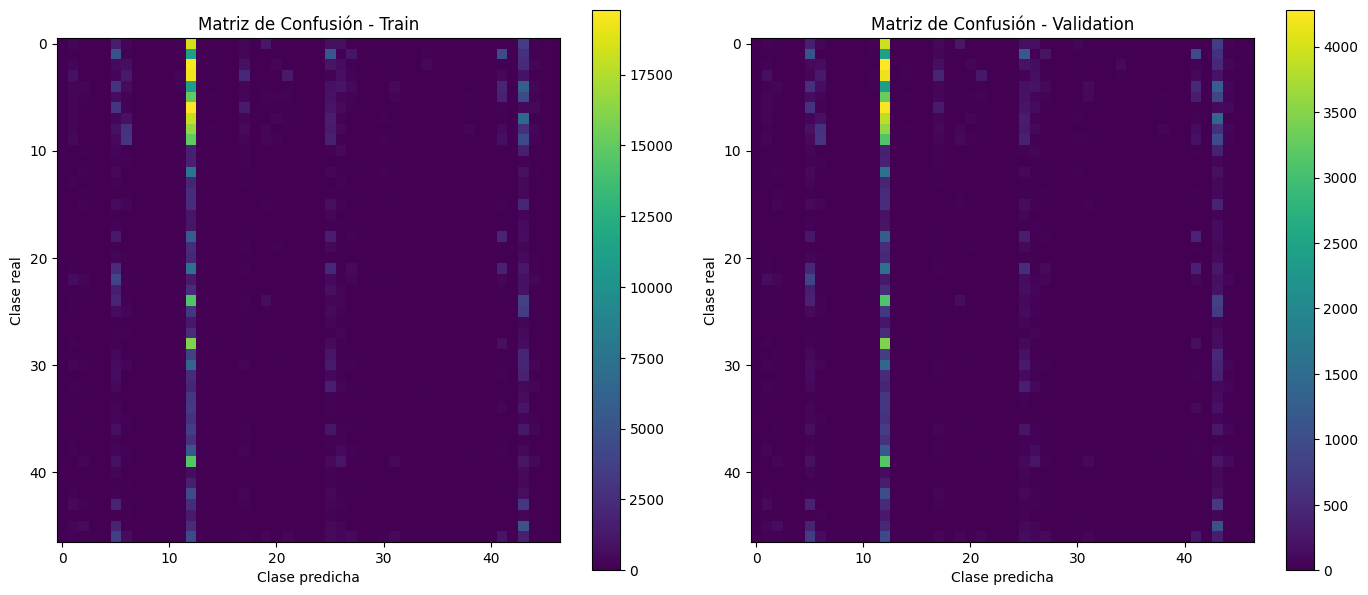

In [ ]:
visual.graficar_matrices_confusion(matriz_train, matriz_val)